# Verkkoteoria

Verkkoteoriaa sovelletaan tapauksissa, joissa on useita samanaikaisia tapahtumia. Osa tapahtumista on samanaikaisia, osa taas peräkkäisiä. Samoin osa tapahtumista voi olla muista riippumattomia, osa taas riippuu joistain muista jollain tavalla. 

Tyypillisiä esimerkkejä tällaisista sovelluksista ovat projektien aikataulutus ja niiden hallinta. Alun perin tällaiset sovellukset on kehitetty Yhdsyvalloissa toisen maailmansodan aikana ja lainattu sieltä sitten yritysmaailmaan.

### Esimerkki. Aamutoimet

0. Herääminen --> Valmis siirtymään joukkoliikennevälineeseen.

Toimintoja:
1. aamupalan valmistus (15 min)
2. suihku (20 min)
3. petaus (2 min)
4. lehden lukeminen (30 min)
5. aamupalan syönti (25 min)
6. pukeutuminen (5 min)
7. hampaiden harjaus (2 min)
8. meikkaus (6 min)

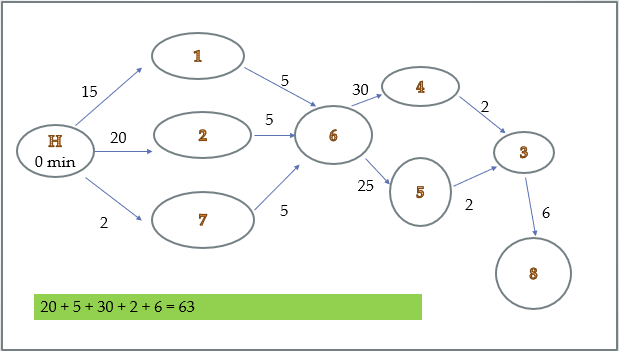

__Time earliest expected $T_E$__: ensimmäinen ajankohta, jolloin kukin toimintoa voi olla valmis 

In [8]:
import pandas as pd

### Muodostetaan aamutoimista tietokehys

aamutoimet = pd.DataFrame({'Toiminnot' : ['0 herääminen',
                                           '1 aamupalan valmistus',
                                           '2 suihku',
                                           '7 hampaiden harjaus',
                                           '6 pukeutuminen',
                                           '4 lehden lukeminen',
                                           '5 aamupalan syönti',
                                           '3 petaus',
                                           '8 meikkaus',
                                           'valmis siirtymään bussiin'],
                         'Minuuttia' : [0, 15, 20, 2, 5, 30, 25, 2, 6, 0]})

In [9]:
aamutoimet

,Toiminnot,Minuuttia
0,0 herääminen,0
1,1 aamupalan valmistus,15
2,2 suihku,20
3,7 hampaiden harjaus,2
4,6 pukeutuminen,5
5,4 lehden lukeminen,30
6,5 aamupalan syönti,25
7,3 petaus,2
8,8 meikkaus,6
9,valmis siirtymään bussiin,0


In [10]:
## Lisätään Te

aamutoimet.loc[0, 'Te'] = aamutoimet.loc[0, 'Minuuttia']
aamutoimet.loc[1, 'Te'] = aamutoimet.loc[0, 'Te'] + aamutoimet.loc[1, 'Minuuttia']
aamutoimet.loc[2, 'Te'] = aamutoimet.loc[0, 'Te'] + aamutoimet.loc[2, 'Minuuttia']
aamutoimet.loc[3, 'Te'] = aamutoimet.loc[0, 'Te'] + aamutoimet.loc[3, 'Minuuttia']
aamutoimet.loc[4, 'Te'] = max(aamutoimet.loc[1, 'Te'], aamutoimet.loc[2, 'Te'], aamutoimet.loc[3, 'Te']) + aamutoimet.loc[4, 'Minuuttia']
aamutoimet.loc[5, 'Te'] = aamutoimet.loc[4, 'Te'] + aamutoimet.loc[5, 'Minuuttia']
aamutoimet.loc[6, 'Te'] = aamutoimet.loc[4, 'Te'] + aamutoimet.loc[6, 'Minuuttia']
aamutoimet.loc[7, 'Te'] = max(aamutoimet.loc[5, 'Te'], aamutoimet.loc[6, 'Te']) + aamutoimet.loc[7, 'Minuuttia']
aamutoimet.loc[8, 'Te'] = aamutoimet.loc[7, 'Te'] + aamutoimet.loc[8, 'Minuuttia']
aamutoimet.loc[9, 'Te'] = aamutoimet.loc[8, 'Te'] + aamutoimet.loc[9, 'Minuuttia']

In [11]:
aamutoimet

,Toiminnot,Minuuttia,Te
0,0 herääminen,0,0.0
1,1 aamupalan valmistus,15,15.0
2,2 suihku,20,20.0
3,7 hampaiden harjaus,2,2.0
4,6 pukeutuminen,5,25.0
5,4 lehden lukeminen,30,55.0
6,5 aamupalan syönti,25,50.0
7,3 petaus,2,57.0
8,8 meikkaus,6,63.0
9,valmis siirtymään bussiin,0,63.0


__Time latest expected $T_L$__: viimeisin ajankohta, jolloin kunkin toiminnon on oltava valmis tai muuten projekti myöhästyy. 

In [13]:
aamutoimet.loc[9, 'Tl'] = aamutoimet.loc[9, 'Te']
aamutoimet.loc[8, 'Tl'] = aamutoimet.loc[9, 'Tl'] - aamutoimet.loc[9, 'Minuuttia']
aamutoimet.loc[7, 'Tl'] = aamutoimet.loc[8, 'Tl'] - aamutoimet.loc[8, 'Minuuttia']
aamutoimet.loc[6, 'Tl'] = aamutoimet.loc[7, 'Tl'] - aamutoimet.loc[7, 'Minuuttia']
aamutoimet.loc[5, 'Tl'] = aamutoimet.loc[7, 'Tl'] - aamutoimet.loc[7, 'Minuuttia']
aamutoimet.loc[4, 'Tl'] = min(aamutoimet.loc[6, 'Tl'] - aamutoimet.loc[6, 'Minuuttia'], aamutoimet.loc[5, 'Tl'] - aamutoimet.loc[5, 'Minuuttia'])
aamutoimet.loc[3, 'Tl'] = aamutoimet.loc[4, 'Tl'] - aamutoimet.loc[4, 'Minuuttia']
aamutoimet.loc[2, 'Tl'] = aamutoimet.loc[4, 'Tl'] - aamutoimet.loc[4, 'Minuuttia']
aamutoimet.loc[1, 'Tl'] = aamutoimet.loc[4, 'Tl'] - aamutoimet.loc[4, 'Minuuttia']
aamutoimet.loc[0, 'Tl'] = min(aamutoimet.loc[3, 'Tl'] - aamutoimet.loc[3, 'Minuuttia'], aamutoimet.loc[2, 'Tl'] - aamutoimet.loc[2, 'Minuuttia'], aamutoimet.loc[1, 'Tl'] - aamutoimet.loc[1, 'Minuuttia'])

In [14]:
aamutoimet

,Toiminnot,Minuuttia,Te,Tl
0,0 herääminen,0,0.0,0.0
1,1 aamupalan valmistus,15,15.0,20.0
2,2 suihku,20,20.0,20.0
3,7 hampaiden harjaus,2,2.0,20.0
4,6 pukeutuminen,5,25.0,25.0
5,4 lehden lukeminen,30,55.0,55.0
6,5 aamupalan syönti,25,50.0,55.0
7,3 petaus,2,57.0,57.0
8,8 meikkaus,6,63.0,63.0
9,valmis siirtymään bussiin,0,63.0,63.0


In [15]:
aamutoimet['Pelivara'] = aamutoimet['Tl'] - aamutoimet['Te']

In [16]:
aamutoimet

,Toiminnot,Minuuttia,Te,Tl,Pelivara
0,0 herääminen,0,0.0,0.0,0.0
1,1 aamupalan valmistus,15,15.0,20.0,5.0
2,2 suihku,20,20.0,20.0,0.0
3,7 hampaiden harjaus,2,2.0,20.0,18.0
4,6 pukeutuminen,5,25.0,25.0,0.0
5,4 lehden lukeminen,30,55.0,55.0,0.0
6,5 aamupalan syönti,25,50.0,55.0,5.0
7,3 petaus,2,57.0,57.0,0.0
8,8 meikkaus,6,63.0,63.0,0.0
9,valmis siirtymään bussiin,0,63.0,63.0,0.0


Niiden toimien kanssa, joissa ei ole joustoa, on oltava erityisen tarkkana. Jos taas joustoa on, hintaakin voi laittaa alaspäin.

## Gantt-kaavio

Gantt-kaavio on tietyn tyyppinen pylväskuvio. SItä käytetään yleisesti projektien ja aikataulujen suunittelussa ja kuvaamisessa.

Gantt-kaavio sisältää yleensä tehtävien nimet, niiden alku- ja loppupäivät, tehtäviin sidotut työryhmät, prosenttiosuuden, joka tehtävästä on valmis ja projektin tärkeimmät välitavoitteet.

Tehtäväkokonaisuuksien nimet sijoitetaan yleensä Gantt-kaavion pystyakselille aikajärjestykseen. Vaaka-akselissa taas kulkee aika ja kunkin vaakapylvään leveys kuvaa tehtävän toteutuksen kestoa.

Katsotaan seuraavaksi, miten Gantt-kaavio voidaan tehdä Python data-analytiikkan visualisointiin erikoistuneen _matplotlib_-kirjaston avulla.

In [20]:
# Tuodaan kirjastot

# Laskentaa varten

import numpy as np

#Kuvioita varten
import matplotlib
import matplotlib.pyplot as plt

#Ajanhallintaa
import datetime as dt

Luodaan seuraavaksi tietokehys, jossa kuvataan projektin tehtävät ja niihin liittyvät oleelliset tiedot.

In [22]:
df = pd.DataFrame({'task': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L'],
                  'team': ['TKI', 'Kirjanpito', 'Myynti', 'Myynti', 'IT', 'TKI', 'IT', 'Myynti', 'Kirjanpito', 'Kirjanpito', 'Myynti', 'IT'],
                  'start': pd.to_datetime(['20 Sep 2024', '24 Sep 2024', '26 Sep 2024', '30 Sep 2024', '3 Oct 2024', '7 Oct 2024', '10 Oct 2024', '14 Oct 2024', '18 Oct 2024', '23 Oct 2024', '28 Oct 2024', '31 Oct 2024']),
                  'end': pd.to_datetime(['30 Sep 2024', '28 Sep 2024', '30 Sep 2024', '8 Oct 2024', '9 Oct 2024', '18 Oct 2024', '17 Oct 2024', '22 Oct 2024', '23 Oct 2024', '1 Nov 2024', '5 Nov 2024', '5 Nov 2024']),
                  'completion_frac': [1, 1, 1, 1, 1, 0.95, 0.7, 0.35, 0.1, 0, 0, 0]})
df

,task,team,start,end,completion_frac
0,A,TKI,2024-09-20,2024-09-30,1.00
1,B,Kirjanpito,2024-09-24,2024-09-28,1.00
2,C,Myynti,2024-09-26,2024-09-30,1.00
3,D,Myynti,2024-09-30,2024-10-08,1.00
4,E,IT,2024-10-03,2024-10-09,1.00
5,F,TKI,2024-10-07,2024-10-18,0.95
6,G,IT,2024-10-10,2024-10-17,0.70
7,H,Myynti,2024-10-14,2024-10-22,0.35
8,I,Kirjanpito,2024-10-18,2024-10-23,0.10
9,J,Kirjanpito,2024-10-23,2024-11-01,0.00


Tähän aineistoon liittyvään Gantt-kaavioon tarvitaan vielä neljä saraketta seuraavia tietoja varten:

1. Kuinka monta päivää kuluu projektin aloittamisesta tehtävän aloitukseen (edellä start). Tämä sarake on alla nimeltään _days_to_start_.

2. Kuinka monta päivää kuluu projektin aloittamisesta tehtävän lopetukseen (edellä end). Tämä sarake on alla nimeltään _days_to_end_.

3. Kunkin tehtävän kesto, __aloitus- ja lopetuspäivä mukaan lukien__. Tämä sarake on alla nimeltään _task_duration_.

4. Kuinka suuri osa tehtävästä on valmiina kuvattuna päivinä tehtävän kokonaiskestosta. Tämä sarake on alla nimeltään _completion_days_.

In [24]:
df['days_to_start'] = (df['start'] - df['start'].min()).dt.days

df['days_to_end'] = (df['end'] - df['start'].min()).dt.days

df['task_duration'] = df['days_to_end'] - df['days_to_start'] + 1  # Huomaa ykkönen. Näin saadaan aloitus- ja lopetuspäivät mukaan.

df['completion_days'] = df['completion_frac'] * df['task_duration']

df

,task,team,start,end,completion_frac,days_to_start,days_to_end,task_duration,completion_days
0,A,TKI,2024-09-20,2024-09-30,1.00,0,10,11,11.00
1,B,Kirjanpito,2024-09-24,2024-09-28,1.00,4,8,5,5.00
2,C,Myynti,2024-09-26,2024-09-30,1.00,6,10,5,5.00
3,D,Myynti,2024-09-30,2024-10-08,1.00,10,18,9,9.00
4,E,IT,2024-10-03,2024-10-09,1.00,13,19,7,7.00
5,F,TKI,2024-10-07,2024-10-18,0.95,17,28,12,11.40
6,G,IT,2024-10-10,2024-10-17,0.70,20,27,8,5.60
7,H,Myynti,2024-10-14,2024-10-22,0.35,24,32,9,3.15
8,I,Kirjanpito,2024-10-18,2024-10-23,0.10,28,33,6,0.60
9,J,Kirjanpito,2024-10-23,2024-11-01,0.00,33,42,10,0.00


Nyt voidaankin tehdä perusmuotoinen Gantt-kaavio tälle projektille.

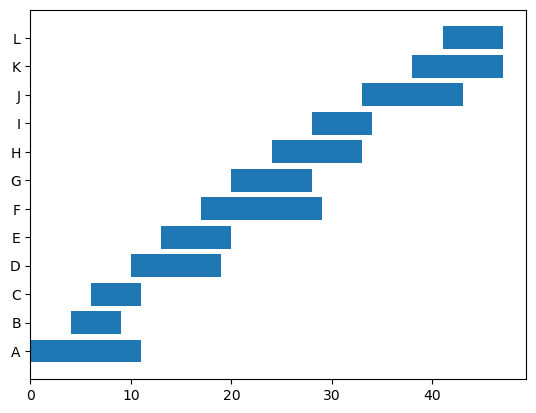

In [26]:
plt.barh(y=df['task'], width=df['task_duration'], left=df['days_to_start'])
plt.show()

Tätä kaaviota on kuitenkin muokattava ennen kuin siitä saadaan kaikki tarvittava tieto hyödynnettyä.

* Lisätään kaavion ja vaaka-akselin otsikko.
* Muunnetaan pystyakseli aikajärjestykseen ylhäältä alkaen.
* Lisätään taustaruudukko.
* Väritetään tehtävät työryhmittäin.
* Lisätään selitteet.
* Lisätään valmiin tehtävän osuudet.

Monissa projektin tehtävissä on kaksi tai useampia osatehtäviä. Tällaiset pystytään käsittelemään matplotlib-kirjaston _broken_barh()_:lla.

Jotta päästään soveltamaan myös tätä ominaisuutta, muokataan aineistoa vielä seuraavasti.

1. Otetaan alkuperäisestä aineistosta vain ne, jotka kuuluvat Myynti-työryhmälle.

2. Nimetään sarakkeet <code>start</code> ja <code>end</code> sarakkeiksi <code>start_1</code> ja <code>end_1</code>.

3. Lisätään tehtäviin osatehtäviä.

4. Lisätään jokaiseen osatehtävään kolme saraketta ja lisätään niihin seuraavat tiedot.
  * Kuinka monta päivää kuluu projektin aloittamisesta jokaisen osatehtävän aloittamiseen.
  * Kuinka monta päivää kuluu projektin aloittamisesta jokaisen osatehtävän lopettamiseen.
  * Jokaisen osatehtävän kesto, aloitus- ja lopetuspäivät mukaan lukien.

In [29]:
# 1
df2 = df[df['team']=='Myynti'][['task', 'team', 'start', 'end']]

# 2
df2.rename(columns={'start': 'start_1', 'end': 'end_1'}, inplace=True)
df2.reset_index(drop=True, inplace=True)

# 3
df2['start_2'] = pd.to_datetime([None, '10 Oct 2024', '25 Oct 2024', None])
df2['end_2'] = pd.to_datetime([None, '14 Oct 2024', '28 Oct 2024', None])
df2['start_3'] = pd.to_datetime([None, None, '1 Dec 2024', None])
df2['end_3'] = pd.to_datetime([None, None, '5 Dec 2024', None])

# 4
for i in [1, 2, 3]:
    suffix = '_' + str(i)
    df2['days_to_start' + suffix] = (df2['start' + suffix] - df2['start_1'].min()).dt.days
    df2['days_to_end' + suffix] = (df2['end' + suffix] - df2['start_1'].min()).dt.days
    df2['task_duration' + suffix] = df2['days_to_end' + suffix] - df2['days_to_start' + suffix] + 1


df2

,task,team,start_1,end_1,start_2,end_2,start_3,end_3,days_to_start_1,days_to_end_1,task_duration_1,days_to_start_2,days_to_end_2,task_duration_2,days_to_start_3,days_to_end_3,task_duration_3
0,C,Myynti,2024-09-26,2024-09-30,NaT,NaT,NaT,NaT,0,4,5,NaN,NaN,NaN,NaN,NaN,NaN
1,D,Myynti,2024-09-30,2024-10-08,2024-10-10,2024-10-14,NaT,NaT,4,12,9,14.0,18.0,5.0,NaN,NaN,NaN
2,H,Myynti,2024-10-14,2024-10-22,2024-10-25,2024-10-28,2024-12-01,2024-12-05,18,26,9,29.0,32.0,4.0,66.0,70.0,5.0
3,K,Myynti,2024-10-28,2024-11-05,NaT,NaT,NaT,NaT,32,40,9,NaN,NaN,NaN,NaN,NaN,NaN


Huomaa, että tehtävillä C ja K on yksi osatehtävä, tehtävällä D kaksi osatehtävää ja tehtävällä H kolme osatehtävää. Sovelletaan siis toimintoa <code>broken_barh()</code> tehtäviin D ja H. Toiminnon tarvittavat parametrit ovat

* <code>xranges</code> &ndash; jono monikkoja (<code>xmin</code>, <code>xwidth</code>), jotka kertovat kunkin pylvään aloituksen ja pituuden. Tällä parametrilla ilmaistaan kunkin osatehtävän aloitus ja kesto.
* <code>yrange</code> &ndash; muotoa (<code>ymin</code>, <code>yheight</code>) oleva monikko, jolla kerrotaan kunkin pylvään pystyakselin kohta korkeus.

Piirretään seuraavaksi Gantt-kaavio, jossa on osatehtäviä. Tämä tapahtuu seuraavasti.

1. Luodaan ensin kuvio, joka koostuu useammasta kaaviosta.

2. Käydään aineisto (tietokehys) läpi rivi riviltä ja tarkistetaan, onko tehtävällä yksi, kaksi vai kolme osatehtävää. Lukumäärästä riippuen
   * __Yksi osatehtävä__: piirretään pylväs käyttäen <code>barh()</code>-toimintoa.
   * __Kaksi osatehtävää__: piirretään kaksi pylvästä käyttäen <code>broken_bar()</code>-toimintoa.
   * __Kolme osatehtävää__: piiretään kolme pylvästä käyttäen <code>broken_bar()</code>-toimintoa.

3. Muokataan kaavion akselit asianmukaisesti.

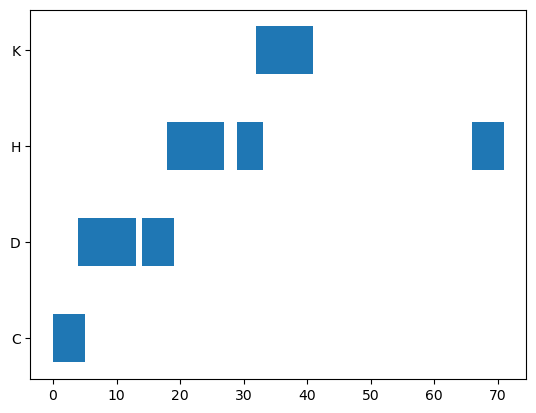

In [32]:
# 1
fig, ax = plt.subplots()

# 2
for index, row in df2.iterrows():
    if row['start_2'] is None:
        ax.barh(y=df2['task'], width=df2['task_duration_1'], left=df2['days_to_start_1'])
    elif row['start_2'] is not None and row['start_3'] is None:
        ax.broken_barh(xranges=[(row['days_to_start_1'], row['task_duration_1']), (row['days_to_start_2'], row['task_duration_2'])], yrange=(index + 1, 0.5))
    else:
        ax.broken_barh(xranges=[(row['days_to_start_1'], row['task_duration_1']), (row['days_to_start_2'], row['task_duration_2']), (row['days_to_start_3'], row['task_duration_3'])], yrange=(index + 1, 0.5))

# 3
ax.set_yticks([1.25, 2.25, 3.25, 4.25])
ax.set_yticklabels(df2['task'])

plt.show()

Yllä olevassa koodissa voidaan itse asiassa käyttää <code>broken_barh()</code>-toimintoa myös niihin tehtäviin, jotka koostuvat vain yhdestä osatehtävästä. Sillä tavoin koodista tulee toki selkeämpää. 

Jos näin haluaa tehdä, koodirivi

In [34]:
ax.barh(y=df2['task'], width=df2['task_duration_1'], left=df2['days_to_start_1'])

<BarContainer object of 4 artists>

tulee korvata koodirivillä

In [36]:
ax.broken_barh(xranges=[(row['days_to_start_1'], row['task_duration_1'])], yrange=(index + 1, 0.5))

## Gantt-kaavion muokkaaminen

Palataanpas alkuperäiseen aineistoon.

In [39]:
df

,task,team,start,end,completion_frac,days_to_start,days_to_end,task_duration,completion_days
0,A,TKI,2024-09-20,2024-09-30,1.00,0,10,11,11.00
1,B,Kirjanpito,2024-09-24,2024-09-28,1.00,4,8,5,5.00
2,C,Myynti,2024-09-26,2024-09-30,1.00,6,10,5,5.00
3,D,Myynti,2024-09-30,2024-10-08,1.00,10,18,9,9.00
4,E,IT,2024-10-03,2024-10-09,1.00,13,19,7,7.00
5,F,TKI,2024-10-07,2024-10-18,0.95,17,28,12,11.40
6,G,IT,2024-10-10,2024-10-17,0.70,20,27,8,5.60
7,H,Myynti,2024-10-14,2024-10-22,0.35,24,32,9,3.15
8,I,Kirjanpito,2024-10-18,2024-10-23,0.10,28,33,6,0.60
9,J,Kirjanpito,2024-10-23,2024-11-01,0.00,33,42,10,0.00


ja ensinki tekemäämme Gantt-kaavioon

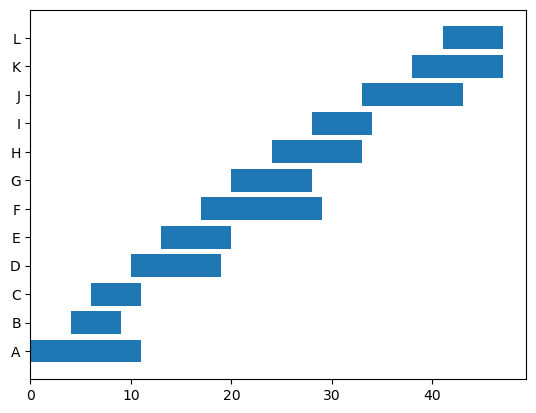

In [41]:
plt.barh(y=df['task'], width=df['task_duration'], left=df['days_to_start'])
plt.show()

Tätä lähtökohtaa on hyvä muokata, jotta se hyödyttää projektin aikataulun hallinnassa parhaalla mahdollisella tavalla. Tehdään seuraavaksi tähän Gantt-kaavioon ja kuvioihin yleisestikin liittyviä perusmuokkauksia.

### Perusmuotoilut

* Lisätään kuvion otsikko.
* Lisätään akselien otsikko ja muotoiluja.
* Lisätään taustaruudukko

#### Lisätään otsikko

Jokaisella kuviolla tulisi olla kuvaava otsikko, niin myös Gantt-kaaviolla.

Jos projektin nimni olisi P, kuvio ja se otsikko voisi olla esim.

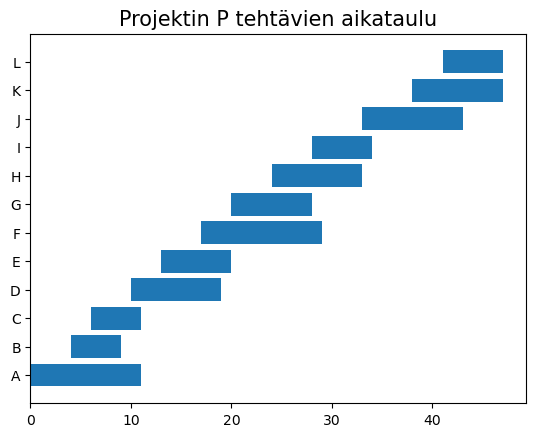

In [47]:
plt.barh(y=df['task'], width=df['task_duration'], left=df['days_to_start'])
plt.title('Projektin P tehtävien aikataulu', fontsize=15)
plt.show()

#### Muunnetaan ja säädetään akseleita ja lisätään taustaruudukko

Täydennetään seuraavaksi aiempaa koodia ja lisätään seuraavat asiat.

1. Luodaan usean kaavion kuvio, jotta päästään työstämään <code>ax</code>-objektia.

2. Käännetään pystyakseli niin, että tehtävät ovat aikajärjestyksestä ylhäältä alkaen.

3. Selvitetään vaaka-akselin lukujen sijainnit:
* Jos esim. halutaan x-akselien päivien alkavan aina maanataista, huomioidaan se, että projekti P alkaakin torstaina.
* Valitaan vain tärkeimmät päivät (major ticks), jotta merkinnät pysyvät selkeinä.

4. Selvitetään ja lisätään asianmukaiset x-akselin merkinnät ja niiden muotoilut.
* Esim. lisätään vaaka-akseliin vain maanantait, vaikka projekti alkaakin torstaina.
* Jos koko projekti tapahtuu yhden vuoden aikana, vuosiluvut ovat muotoilussa turhia.
* Vaaka-akselin merkit on syytä mahtua niille varatuille paikoille.

5. Lisätään edellä selvitetyt vaaka-akselin merkinnät muotoiluineen.

6. Lisätään taustaruudukko.

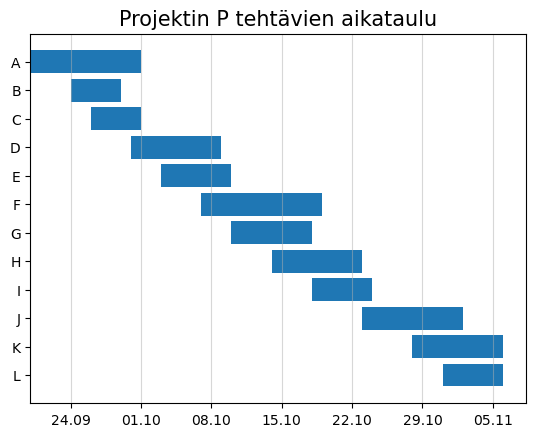

In [50]:
# 1
fig, ax = plt.subplots()

plt.barh(y=df['task'], width=df['task_duration'], left=df['days_to_start'] + 1)
plt.title('Projektin P tehtävien aikataulu', fontsize=15)

# 2
plt.gca().invert_yaxis()

# 3
xticks = np.arange(5, df['days_to_end'].max() + 2, 7)

# 4
xticklabels = pd.date_range(start=df['start'].min() + dt.timedelta(days=4), end=df['end'].max()).strftime("%d.%m")
# 5
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels[::7])

# 6
ax.xaxis.grid(True, alpha=0.5)

plt.show()

### Väritetään tehtävät työryhmien mukaan

Väritetään seuraavaksi kukin palkki (joista kukin edustaa yhtä tehtävää) työryhmän mukaan. Tämä tapahtuu seuraavien vaiheiden kautta.

1. Luodaan Pythonin sanakirja, jossa työryhmien nimet yhdistetään omiin väreihinsä.

2. Luodaan usean kaavion kuvio.

3. Käydään läpi aineisto rivi riviltä ja luodaan jokaista riviä varten oma pylväs ja väritetään se työryhmän värin mukaan.

4. Lisätään muutkin edellä tehdyt muokkaukset.

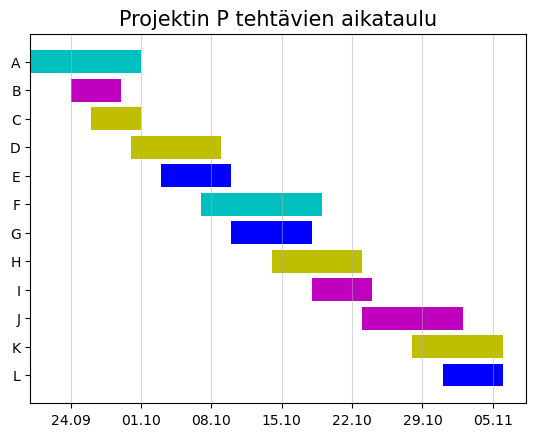

In [53]:
# 1
team_colors = {'TKI': 'c', 'Kirjanpito': 'm', 'Myynti': 'y', 'IT': 'b'}

# 2
fig, ax = plt.subplots()

# 3
for index, row in df.iterrows():
    plt.barh(y=row['task'], width=row['task_duration'], left=row['days_to_start'] + 1, color=team_colors[row['team']])

# 4
plt.title('Projektin P tehtävien aikataulu', fontsize=15)
plt.gca().invert_yaxis()
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels[::7])
ax.xaxis.grid(True, alpha=0.5)
plt.show()

#### Lisätään selite

Eräs varsin oleellinen luettavuutta hankaloittava seikka on, että yllä olevasta kaaviosta puuttuvat selitteet, mikä väri vastaa mitäkin työryhmää. Tätä varten luodaan lista valmiiksi väritetyistä lappusista, jotka sitten yhdistetään työryhmiin. Tässä hyödynnetään matplotlibin toiminnallisuutta [matplotlib.patches.Patch](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Patch.html).

In [56]:
patches = []
for team in team_colors:
    patches.append(matplotlib.patches.Patch(color=team_colors[team]))

Lopulta voidaan lisätä selitteet.

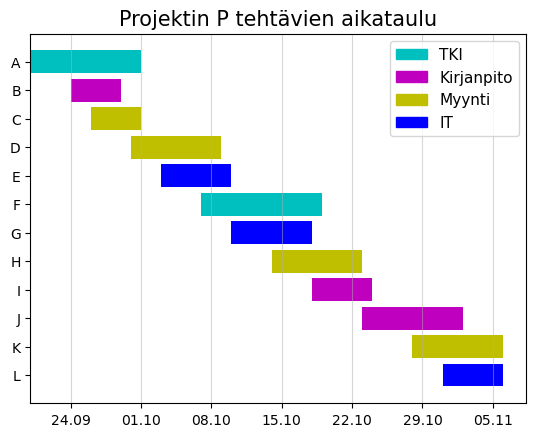

In [58]:
fig, ax = plt.subplots()
for index, row in df.iterrows():
    plt.barh(y=row['task'], width=row['task_duration'], left=row['days_to_start'] + 1, color=team_colors[row['team']])
plt.title('Projektin P tehtävien aikataulu', fontsize=15)
plt.gca().invert_yaxis()
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels[::7])
ax.xaxis.grid(True, alpha=0.5)

# Adding a legend
ax.legend(handles=patches, labels=team_colors.keys(), fontsize=11)

plt.show()

Lähtökohtaan nähden tämä Gantt-kaavio on jo huomattavasti selkeälukuisempi.

### Lisätään tilannetieto

Tähän mennessä ei ole vielä hyödynnetty <code>completion_days_column</code>-saraketta, joka alussa lisättiin projektin tehtävien valmistumisasteen seuraamista varten. Lisätään vielä tämä tieto kaavioon.

Seuraavassa lisätään jokaisen jo tehdyn pylvään päälle uusi pylväs. Alempi pylväs kuvaa tehtävän kokonaiskestoa ilmoitettuina päivinä ja ylemmässä seurataan tehtävän valmistumista noina päivinä. 

Jokaisessa tehtävässä kumpikin pylväs on samanvärinen ja väri vastaa tehtävään liitettyä työryhmää, mutta alempi pylväs on sävyltään vaaleampi.

Jos työryhmä suoriutuu tehtävässään _suunniteltua paremmin_, se näkyy näistä kahdesta pylväästä kuin työryhmä olisi käyttänyt siihen enemmän aika kuin mitä siihen oli tähän asti suunniteltu (jolloin tehtävä oletettavasti valmistuu ennen määräaikaa).

Mikäli taas työryhmä on _suunnitelmaa jäljessä_, pylväistä pystyy lukemaan, että siihen on käytetty vähemmän aikaa kuin mitä siihen suunnitelman mukaan olisi mennyt (jolloin tehtävä oletettavasti valmistuu määräajan jälkeen). 

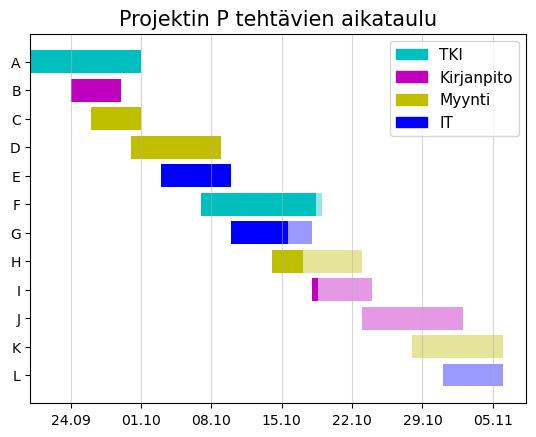

In [64]:
fig, ax = plt.subplots()

for index, row in df.iterrows():

    # Adding a lower bar - for the overall task duration
    plt.barh(y=row['task'], width=row['task_duration'], left=row['days_to_start'] + 1, color=team_colors[row['team']], alpha=0.4)

    # Adding an upper bar - for the status of completion
    plt.barh(y=row['task'], width=row['completion_days'], left=row['days_to_start'] + 1, color=team_colors[row['team']])

plt.title('Projektin P tehtävien aikataulu', fontsize=15)
plt.gca().invert_yaxis()
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels[::7])
ax.xaxis.grid(True, alpha=0.5)
ax.legend(handles=patches, labels=team_colors.keys(), fontsize=11)
plt.show()

Yllä olevasta kuviosta näkeekin, että työryhmät eivät ole samassa tahdissa tehtävien suorittamisen suhteen. Näinhän tilanne usein on todellisissa projekteissa. Oletetaan tämän päivän päivämääräksi 17.10.2024 ja lisätään se kuvioon.

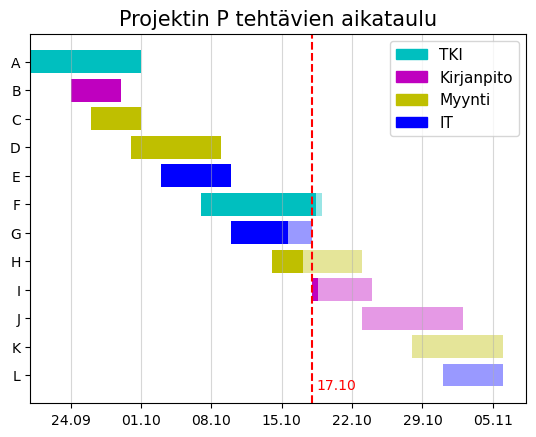

In [66]:
fig, ax = plt.subplots()
for index, row in df.iterrows():
    plt.barh(y=row['task'], width=row['task_duration'], left=row['days_to_start'] + 1, color=team_colors[row['team']], alpha=0.4)
    plt.barh(y=row['task'], width=row['completion_days'], left=row['days_to_start'] + 1, color=team_colors[row['team']])

plt.title('Projektin P tehtävien aikataulu', fontsize=15)
plt.gca().invert_yaxis()
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels[::7])
ax.xaxis.grid(True, alpha=0.5)
ax.legend(handles=patches, labels=team_colors.keys(), fontsize=11)

# Marking the current date on the chart
ax.axvline(x=29, color='r', linestyle='dashed')
ax.text(x=29.5, y=11.5, s='17.10', color='r')

plt.show()

Tästä Gantt-kaaviosta voidaan todeta projektin P nykytilasta seuraavia huomioita.

* TKI-työryhmä on suoriutunut tehtävässä F suunnitelmaa nopeammin ja oletettavasti saa sen valmiiksi ennen määräaikaa.

* IT-työryhmä ei ole saanut tehtävää G valmiiksi määräajassa ja tehtävään tarvitaan lisätukea.

* Myynti-työryhmä on jäljessä tehtävässä H ja ja tarvitsee mahdollisesti tukea saadakseen tehtävän valmiiksi määräajassa.

* Kirjanpito-työryhmä on aikataulua edellä tehtävässä I.

Tällaisten huomioiden tarkoitus on auttaa muuttamaan projektin aikataulua todellisen tilanteen mukaan ja siirtämään resursseja tarvittaviin kohteisiin, jotta projektin kokonaisaikataulussa pysyttäisiin mahdollisimman hyvin.

### Mahdollisia muita parannuskohteita

Gantt-kaavioon voidaan lisätä matplotlibiä hyödyntäen myös muita yksityiskohtia. Tällaisia voisivat olla seuraavat.

* Tehtävän valmiin osuuden prosenttiluvun lisääminen.

* Tehtävän jakaminen osatehtäviin (kuten aiemmin jo käsiteltiin).

* Huomioida toisiinsa liittyvät tehtävät.

* Merkittävien välitavoitteiden ja määräpäivien lisääminen.

* Viikonloppujen ja juhlapyhien korostaminen.

* Pylväiden järjestäminen työryhmittäin tai tehtävätyypeittäin.

* Yksityiskohtien lisääminen vaaka-akseliin.

* Muotoilujen ja sommittelun parantaminen.

Kuten visualisoinnissa yleensäkin, on kuitenkin muistettava pitää myös Gantt-kaaviot selkeinä ja välttää liiallista yksintyiskohtien tulvaa. Tarjotun tiedon määrän ja luettavuuden välisen sopivaan tasapainon löytämiseen on syytä kiinnittää huomiota.

Lähdekirjallisuutta: [How to Make a Gantt Chart in Python with Matplotlib](https://www.datacamp.com/tutorial/how-to-make-gantt-chart-in-python-matplotlib)

In [71]:
import datetime
import pytz

tz = pytz.timezone('Europe/Helsinki')
print(f'Last modified {tz.localize(datetime.datetime.now()):%Y-%m-%d %H:%M} by Juha Nurmonen')

Last modified 2026-02-04 21:02 by Juha Nurmonen
